In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zynicide/wine-reviews")

#print("Path to dataset files:", path)

ANÁLISIS DE DATOS EXPLORATORIO Y LIMPIEZA DE DATOS
Se explora el dataset winemag-data_first150k.csv y se hace limpieza básica de datos así como análisis estadístico general.
-valores nulos
-limpieza de texto
-analisis estadístico
-visualización de datos 
-correlación de variables numéricas 

In [3]:
file_path = Path(path)/"winemag-data_first150k.csv"


df=pd.read_csv(file_path)
df.sample(7).transpose()

,119264,126657,106147,80276,35150,142678,73363
Unnamed: 0,119264,126657,106147,80276,35150,142678,73363
country,US,Chile,US,Germany,Germany,France,France
description,"Thin and vegetal, with barely ripened cherry f...","Rich, with thick but appealing tar, chocolate ...",This is a little rough and scouring on the mou...,Sweet-tart red cherry and pastry notes are ent...,Touches of autumn leaves and dried herbs lend ...,97-99 Barrel sample. A superb wine that brings...,"Benefiting from the ripe 2009 vintage, the win..."
designation,NaN,Reserva,Brut de Blancs,Alte Reben,Gutsriesling Dry,Barrel sample,Les Forges
points,82,87,87,86,87,98,87
price,15.0,18.0,28.0,77.0,21.0,NaN,NaN
province,California,Curicó Valley,California,Baden,Nahe,Bordeaux,Burgundy
region_1,El Dorado,NaN,Arroyo Grande Valley,NaN,NaN,Saint-Émilion,Bourgogne Hautes Côtes de Beaune
region_2,Sierra Foothills,NaN,Central Coast,NaN,NaN,NaN,NaN
variety,Tempranillo,Carmenère,Sparkling Blend,Spätburgunder,Riesling,Bordeaux-style Red Blend,Pinot Noir


In [4]:
print(f"INFORMACIÓN GENERAL DEL DATASET")
print({df.info()})
print("~"*50)
print(f"VALORES NULOS")
print(df.isnull().sum())
print('~'*50)
print(f"PORCENTAJE DE VALORES NULOS")
print(df.isnull().sum()*100/len(df))


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 150930 entries, 0 to 150929
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   150930 non-null  int64  
 1   country      150925 non-null  str    
 2   description  150930 non-null  str    
 3   designation  105195 non-null  str    
 4   points       150930 non-null  int64  
 5   price        137235 non-null  float64
 6   province     150925 non-null  str    
 7   region_1     125870 non-null  str    
 8   region_2     60953 non-null   str    
 9   variety      150930 non-null  str    
 10  winery       150930 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 12.7 MB
{None}
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
VALORES NULOS
Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2  

In [5]:
#se remplazan los valores nulos 
temp=df.fillna({'country':'country_unknown','designation':'designation_unknown','price':df['price'].mean(),'province':'province_unknown','region_1':'region_1_unknown','region_2':'region_2_unknown'})
temp.isnull().sum()

Unnamed: 0     0
country        0
description    0
designation    0
points         0
price          0
province       0
region_1       0
region_2       0
variety        0
winery         0
dtype: int64

In [6]:
temp=temp.drop(columns=['Unnamed: 0'])
#duplicados = temp[temp.duplicated(keep=False)]

# Agrupar por todas las columnas para ver qué filas son iguales
#grupos = temp.groupby(temp.columns.tolist()).apply(lambda x: list(x.index))

#print("Grupos de filas idénticas:")
#for fila, indices in grupos.items():
#    if len(indices) > 1:
#        print(f"Filas {indices} son iguales:")

In [7]:
#Borrar filas iguales 
temp=temp.drop_duplicates()
temp.info()

<class 'pandas.DataFrame'>
Index: 97851 entries, 0 to 149639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      97851 non-null  str    
 1   description  97851 non-null  str    
 2   designation  97851 non-null  str    
 3   points       97851 non-null  int64  
 4   price        97851 non-null  float64
 5   province     97851 non-null  str    
 6   region_1     97851 non-null  str    
 7   region_2     97851 non-null  str    
 8   variety      97851 non-null  str    
 9   winery       97851 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 8.2 MB


ANÁLISIS ESTADÍSTICO DE VARIABLES NUMÉRICAS


In [8]:
temp.head().transpose()

,0,1,2,3,4
country,US,Spain,US,US,France
description,This tremendous 100% varietal wine hails from ...,"Ripe aromas of fig, blackberry and cassis are ...",Mac Watson honors the memory of a wine once ma...,"This spent 20 months in 30% new French oak, an...","This is the top wine from La Bégude, named aft..."
designation,Martha's Vineyard,Carodorum Selección Especial Reserva,Special Selected Late Harvest,Reserve,La Brûlade
points,96,96,96,96,95
price,235.0,110.0,90.0,65.0,66.0
province,California,Northern Spain,California,Oregon,Provence
region_1,Napa Valley,Toro,Knights Valley,Willamette Valley,Bandol
region_2,Napa,region_2_unknown,Sonoma,Willamette Valley,region_2_unknown
variety,Cabernet Sauvignon,Tinta de Toro,Sauvignon Blanc,Pinot Noir,Provence red blend
winery,Heitz,Bodega Carmen Rodríguez,Macauley,Ponzi,Domaine de la Bégude


#quitar valores repetidos 

In [9]:

temp.to_csv('df-clean.csv',index=False)#CREO DATASET SIN VALORES NULOS NI DUPLICADOS
#dfc=pd.read_csv('df-clean.csv')
#dfc.info()
#temp2=dfc.to_csv('ddf-clean.csv')
#temp22=pd.read_csv('ddf-clean.csv')
#temp22.info()

In [10]:
#por ahora descartamos la  descripción
temp=temp.drop(columns=['description'])
num_cols=temp.select_dtypes(include=['int64','float64'])
num_cols.sample(3).transpose()


,64775,61427,53057
points,93.0,88.0,85.0
price,65.0,16.0,18.0


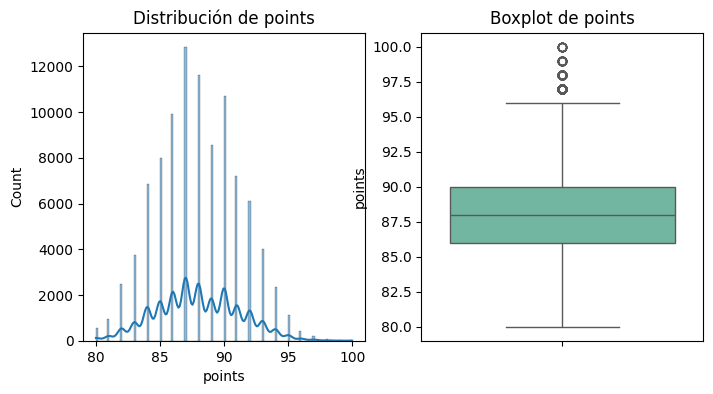

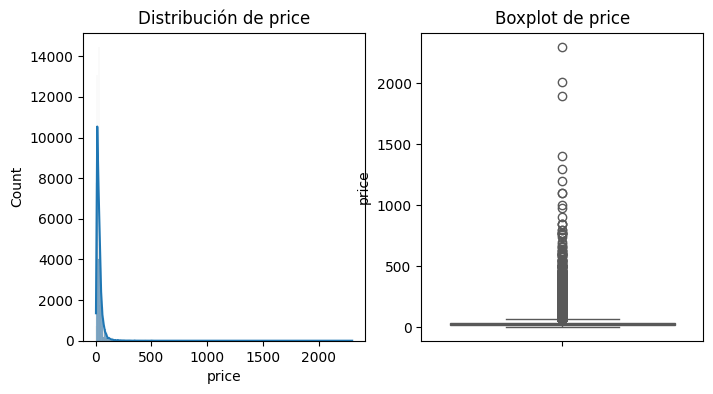

In [11]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.histplot(temp[col],kde=True,palette='Set3')
    plt.title(f'Distribución de {col}')

    plt.subplot(1,2,2)
    sns.boxplot(y=temp[col],palette='Set2')
    plt.title(f'Boxplot de {col}')
    plt.show

ESTADÍSTICA DE VARIABLES CATEGÓRICAS

In [12]:
cat_cols=temp.select_dtypes(include=['object'])
cat_cols.sample(5).transpose()

,32002,117126,21218,7871,10204
country,Spain,Argentina,US,Italy,US
designation,Extremarium Brut Reserva,Premium,designation_unknown,designation_unknown,designation_unknown
province,Catalonia,Mendoza Province,California,Sicily & Sardinia,California
region_1,Cava,Luján de Cuyo,St. Helena,Terre Siciliane,Santa Lucia Highlands
region_2,region_2_unknown,region_2_unknown,Napa,region_2_unknown,Central Coast
variety,Sparkling Blend,Malbec,Sauvignon Blanc,Red Blend,Chardonnay
winery,Mont Marçal,Piattelli,Joseph Phelps,Colosi,Vinum Cellars


distribución de country:
country
US             0.414344
Italy          0.151761
France         0.147765
Spain          0.055625
Chile          0.038170
Portugal       0.035850
Argentina      0.035227
Australia      0.032212
Austria        0.020020
New Zealand    0.019060
Name: proportion, dtype: float64


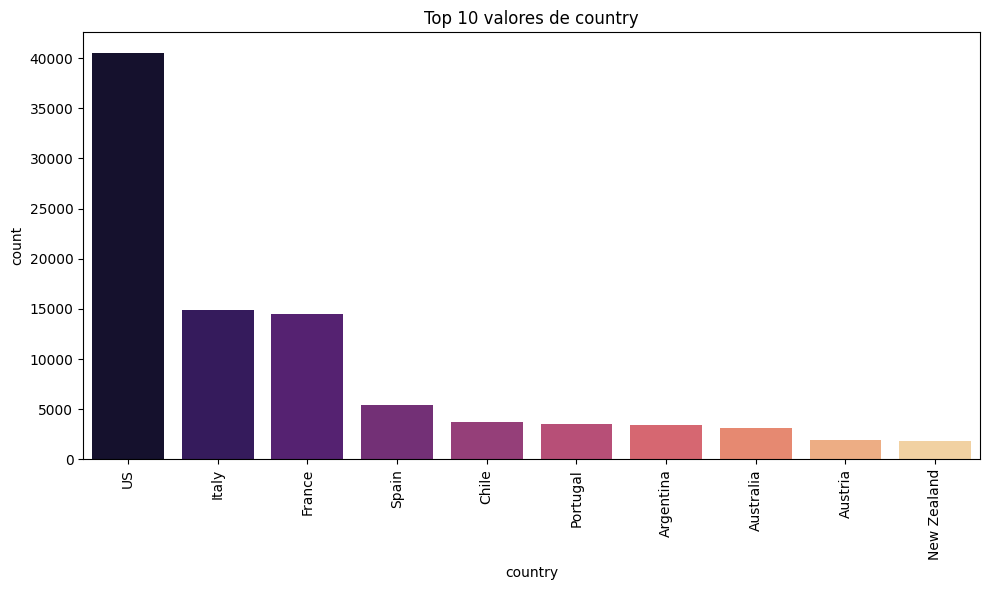

distribución de designation:
designation
designation_unknown    0.305526
Reserve                0.018079
Reserva                0.011528
Estate                 0.010393
Barrel sample          0.007746
Barrel Sample          0.006173
Riserva                0.005181
Brut                   0.004057
Estate Grown           0.003229
Crianza                0.003168
Name: proportion, dtype: float64


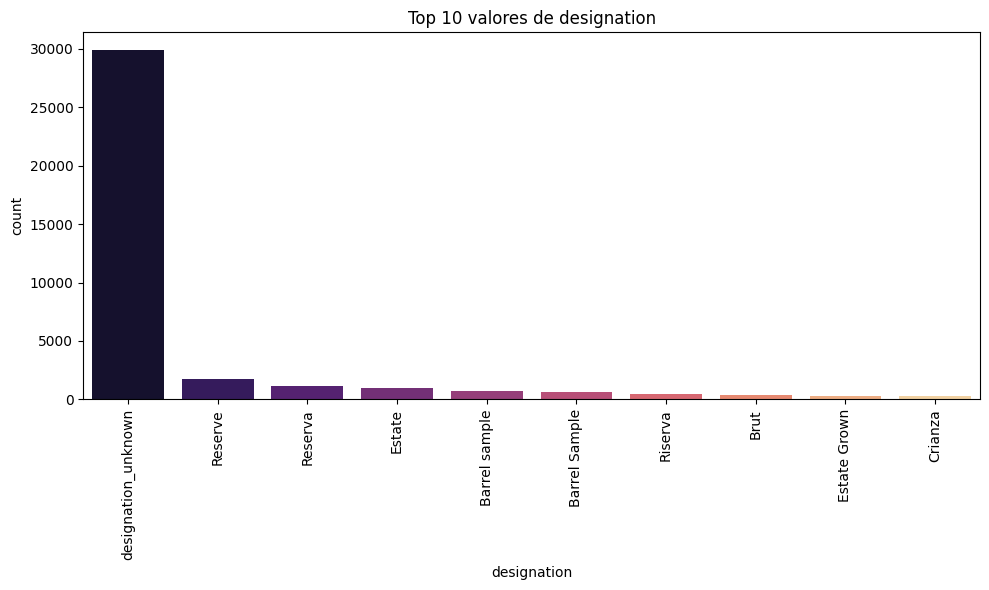

distribución de province:
province
California          0.294325
Washington          0.066213
Tuscany             0.047123
Bordeaux            0.045314
Northern Spain      0.032662
Burgundy            0.029862
Mendoza Province    0.029852
Oregon              0.029320
Veneto              0.025733
Piedmont            0.023372
Name: proportion, dtype: float64


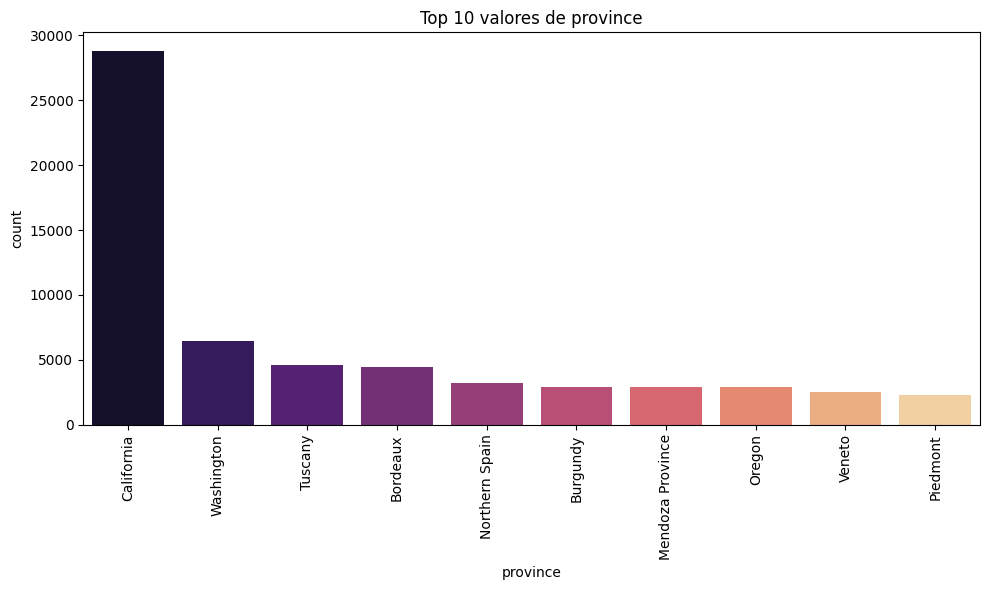

distribución de region_1:
region_1
region_1_unknown        0.162819
Napa Valley             0.042217
Columbia Valley (WA)    0.034072
Russian River Valley    0.023526
California              0.022769
Mendoza                 0.022473
Paso Robles             0.019172
Willamette Valley       0.013040
Rioja                   0.012795
Alsace                  0.012683
Name: proportion, dtype: float64


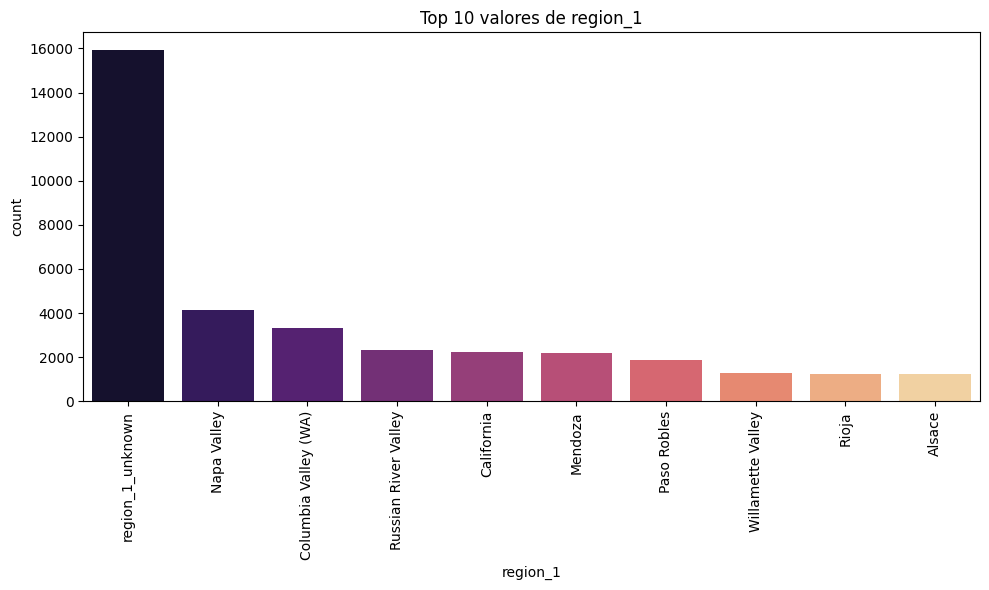

distribución de region_2:
region_2
region_2_unknown           0.596417
Central Coast              0.085620
Sonoma                     0.073316
Columbia Valley            0.062176
Napa                       0.059979
California Other           0.023117
Willamette Valley          0.020225
Mendocino/Lake Counties    0.015922
Sierra Foothills           0.010884
Napa-Sonoma                0.010414
Name: proportion, dtype: float64


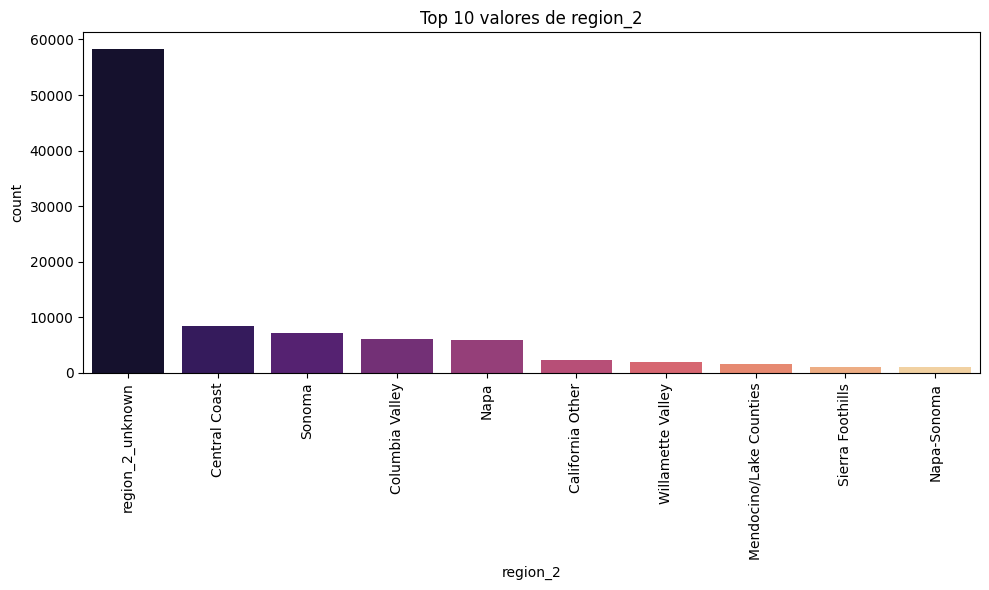

distribución de variety:
variety
Pinot Noir                  0.094869
Chardonnay                  0.093642
Cabernet Sauvignon          0.084537
Red Blend                   0.066274
Bordeaux-style Red Blend    0.052897
Sauvignon Blanc             0.041257
Syrah                       0.037434
Riesling                    0.036637
Merlot                      0.032478
Zinfandel                   0.024619
Name: proportion, dtype: float64


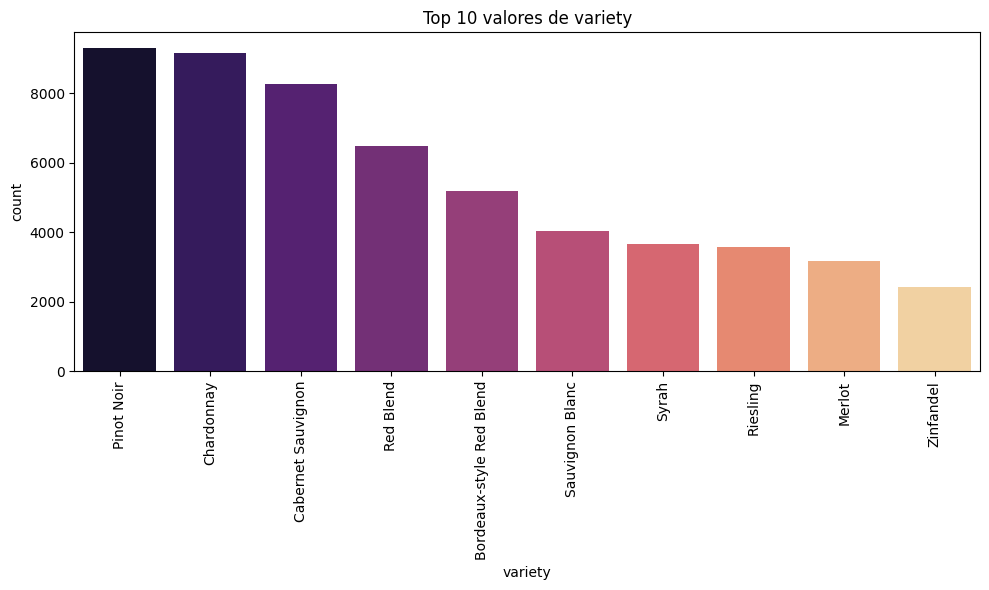

distribución de winery:
winery
Williams Selyem          0.002402
Testarossa               0.001748
Chateau Ste. Michelle    0.001594
Columbia Crest           0.001553
DFJ Vinhos               0.001513
Concha y Toro            0.001349
Georges Duboeuf          0.001318
Kendall-Jackson          0.001277
Joseph Drouhin           0.001237
Trapiche                 0.001226
Name: proportion, dtype: float64


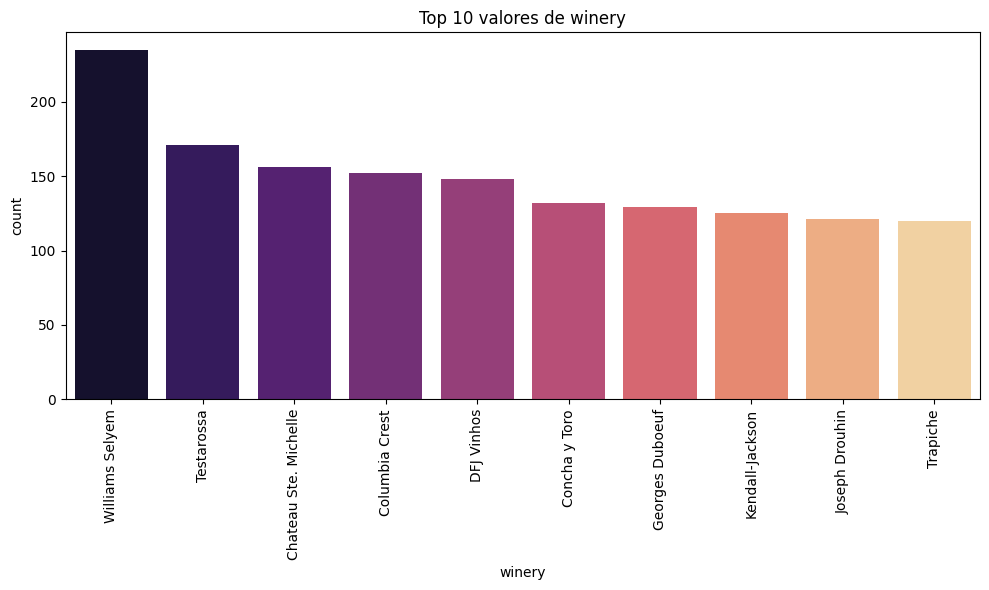

In [13]:
for column in cat_cols:
    print(f'distribución de {column}:')
    print(temp[column].value_counts(normalize=True).head(10))

    top_cat=temp[column].value_counts().head(10).index.tolist()

    temp_filt=temp[temp[column].isin(top_cat)].copy()

     # Crear el gráfico
    plt.figure(figsize=(10, 6))
    
    # Ordenar las categorías por frecuencia (opcional pero recomendado)
    order = temp_filt[column].value_counts().index
    
    sns.countplot(x=column, data=temp_filt, order=order,palette='magma')
    plt.xticks(rotation=90)
    plt.title(f'Top 10 valores de {column}')
    plt.tight_layout()
    plt.show()

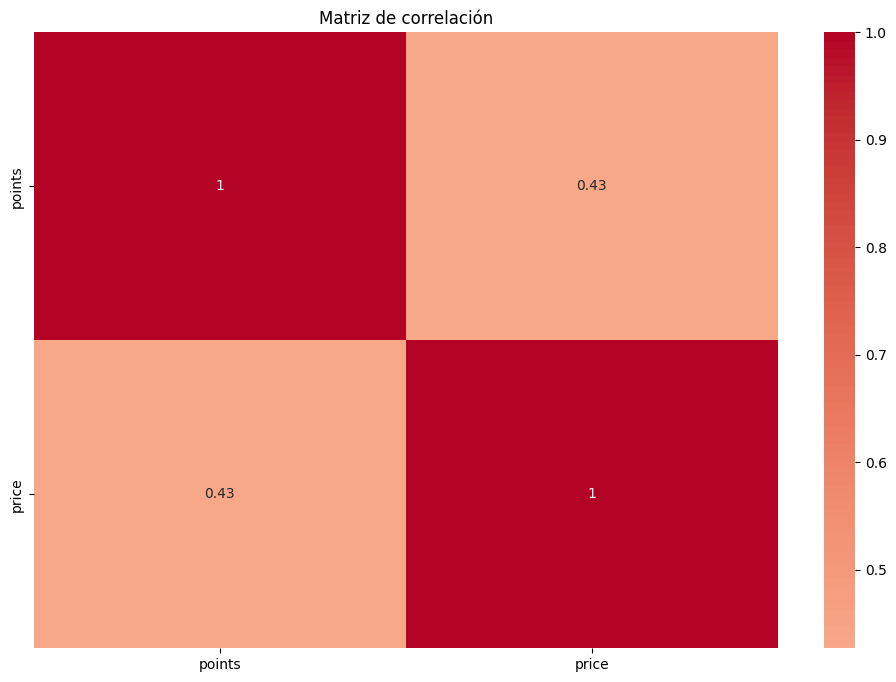

In [14]:
#------------MATRIZ DE CORRELACION--------------------

if len(num_cols)>1:
    plt.figure(figsize=(12,8))
    sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm',center=0)
    plt.title('Matriz de correlación')
    plt.show()